In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [39]:
import kagglehub
path = kagglehub.dataset_download("aman2626786/titanic-toy-dataset")

Using Colab cache for faster access to the 'titanic-toy-dataset' dataset.


In [40]:
df = pd.read_csv(f'{path}/titanic_toy.csv')

In [41]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [42]:
df.isnull().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [43]:
X = df.drop(columns=['Survived'],axis=1)
y = df['Survived']

## Train Test Split

Train Test Split is done for mainly evalutation.Find and learn the statistics from the train data and apply it to the validation data. Make sure not to do transform on both train and test, that will lead to data leakage (eg. very high validation compared to training.)

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
X.shape,y.shape,X_train.shape,y_train.shape,X_test.shape,y_test.shape

((891, 3), (891,), (712, 3), (712,), (179, 3), (179,))

Imputation: Means to fill null values instead of dropping the rows.
Techniques: <br>
1.Mean <br>
2.Median<br>
3.Mode<br>

- Mean/median for numeric and Mode for categorical data.
- These are univariate imputation techniques. Meaning the data is imputated on the basis of the same variable.


In [46]:
# imputer = SimpleImputer(strategy='mean')

# X_train_imputed = imputer.fit_transform(X_train)
# X_test_imputed = imputer.transform(X_test)

In [47]:
# pd.DataFrame(X_train_imputed,columns=X_train.columns).isnull().sum()

In [48]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [49]:
# column transformer for working differently on each column at once
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [50]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [51]:
X_train_imputed= trf.transform(X_train)
X_test_imputed = trf.transform(X_test)

In [52]:
trf.named_transformers_['imputer1'].statistics_,trf.named_transformers_['imputer2'].statistics_

(array([28.]), array([32.51778772]))

In [53]:
X_train_imputed

array([[ 45.5       ,  28.5       ,   0.        ],
       [ 23.        ,  13.        ,   0.        ],
       [ 32.        ,   7.925     ,   0.        ],
       ...,
       [ 41.        ,  32.51778772,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]])

Generally, variance reduces as the imputation is done (since we are replacing missing values with mean/median). But if it decreases significantly then it's a sign that the imputation method may not be appropriate for the data. A significant reduction in variance can indicate that the imputed values are too similar to each other, which can lead to biased results in subsequent analyses.

In [54]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train_imputed[:,0].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after mean imputation: ', X_train_imputed[:,1].var())

Original Age variable variance:  210.2517072477438
Age Variance after median imputation:  168.96965935409042
Original Fare variable variance:  2761.031434948639
Fare Variance after mean imputation:  2617.5508688066407


In [55]:
# change X_train_imputed to dataframe from numpy array for plotting.
X_train_imputed = pd.DataFrame({
    'Age':X_train_imputed[:,0],
    'Fare':X_train_imputed[:,1],
    'Family':X_train['Family']
})

In [56]:
X_train_imputed

,Age,Fare,Family
331,45.5,28.500000,0
733,23.0,13.000000,0
382,32.0,7.925000,0
704,26.0,7.854200,1
813,6.0,31.275000,6
...,...,...,...
106,21.0,7.650000,0
270,28.0,31.000000,0
860,41.0,32.517788,2
435,14.0,120.000000,3


The distribution also changes after imputation. Since age had higher missing values, imputing it caused a significant change in its distribution. But fare had less missing values, so its distribution didn't change much after imputation.
The conclusion is we will have to find another method for age but fare is fine with mean imputation.

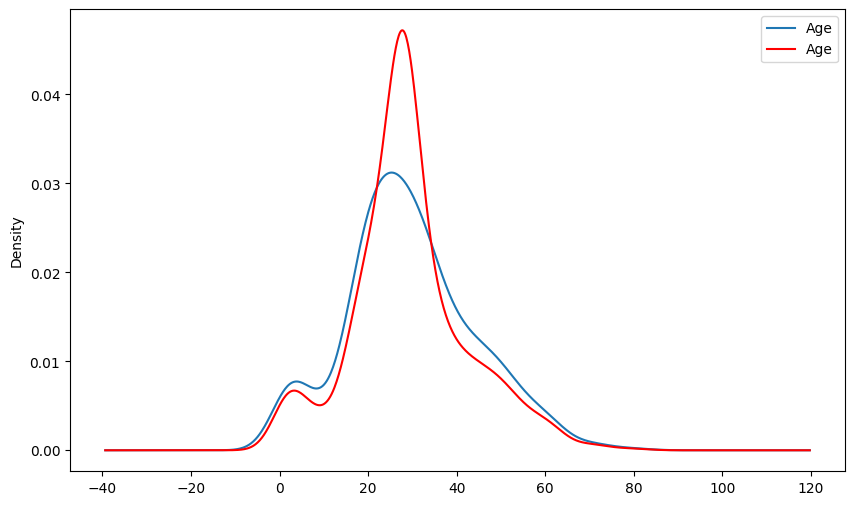

In [57]:
import seaborn as sns

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax)
X_train_imputed['Age'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

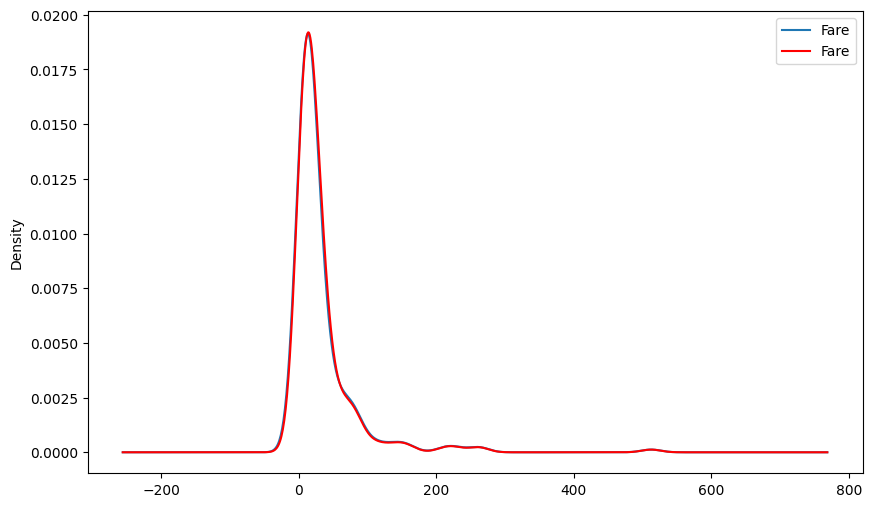

In [58]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind='kde', ax=ax)
X_train_imputed['Fare'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

Random Sample Imputation uses random values from the same variable and fills the missing values.

In [59]:
!pip install feature-engine
from feature_engine.imputation import RandomSampleImputer
RSM = RandomSampleImputer()
X_train_sample_imputed  = RSM.fit_transform(X_train['Age'].values.reshape(-1,1))

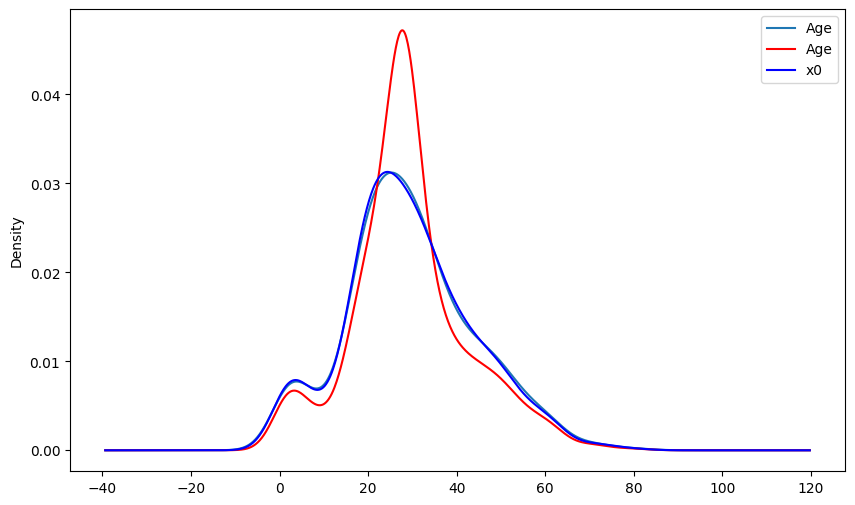

In [60]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax)
X_train_imputed['Age'].plot(kind='kde', ax=ax, color='red')
X_train_sample_imputed.plot(kind='kde',ax=ax,color='blue')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')